# Part 3 External Model Comparison

This notebook compares the scratch CNN baseline against the transfer-learning runs.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

COMPARISON_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_3\outputs\external_model_comparison_2026-04-29_122601")
RUN_NAMES = ['part2_cnn_deep_wide']
RUN_DIRS = {'part2_cnn_deep_wide': 'C:\\Users\\emil_\\vscode\\Assignment1\\part_3\\outputs\\external_model_comparison_2026-04-29_122601\\part2_cnn_deep_wide'}

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


## Summary Table

In [2]:
rows = []
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    config = load_json(run_dir / 'config.json')
    summary = load_json(run_dir / 'summary.json')
    rows.append({
        'model': run_name,
        'backbone': config.get('backbone_name'),
        'transfer_learning': config.get('transfer_learning'),
        'weights': config.get('weights_name'),
        'best_epoch': summary['best_epoch'],
        'best_stage': summary['best_stage'],
        'best_val_loss': summary['best_validation_loss'],
        'best_val_acc': summary['best_validation_accuracy'],
        'test_loss': summary['final_test_loss'],
        'test_acc': summary['final_test_accuracy'],
        'macro_f1': summary['final_test_macro_f1'],
        'time_s': summary['total_training_time_seconds'],
        'test_eval_time_s': summary.get('test_evaluation_time_seconds'),
        'test_total_time_s': summary.get('final_test_total_time_seconds'),
        'test_images_per_s': summary.get('test_evaluation_images_per_second'),
        'test_ms_per_image': summary.get('test_evaluation_time_per_image_ms'),
        'trainable_parameters': summary['trainable_parameters'],
        'total_parameters': summary['total_parameters'],
    })
comparison_df = pd.DataFrame(rows).sort_values(by='test_acc', ascending=False).reset_index(drop=True)
comparison_df

,model,backbone,transfer_learning,weights,best_epoch,best_stage,best_val_loss,best_val_acc,test_loss,test_acc,macro_f1,time_s,test_eval_time_s,test_total_time_s,test_images_per_s,test_ms_per_image,trainable_parameters,total_parameters
0,part2_cnn_deep_wide,part2_cnn_deep_wide,False,None,10,part2_cnn_deep_wide,0.427754,0.815217,0.44622,0.771117,0.718229,242.023253,1.319546,2.701234,278.126025,3.595492,388930,388930


## Accuracy Vs Runtime

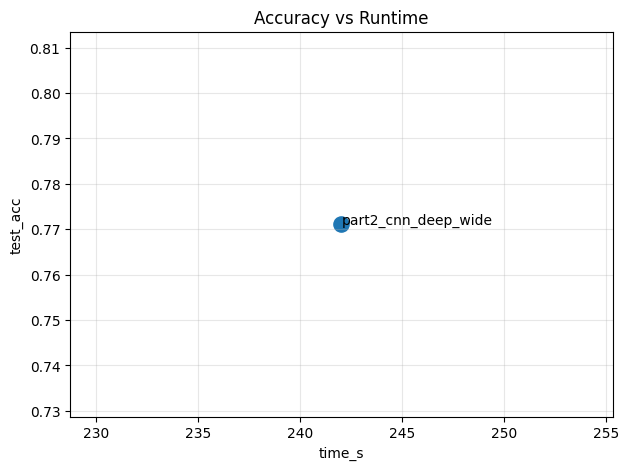

In [3]:
ax = comparison_df.plot.scatter(x='time_s', y='test_acc', s=120, figsize=(7, 5))
for _, row in comparison_df.iterrows():
    ax.annotate(row['model'], (row['time_s'], row['test_acc']))
ax.grid(True, alpha=0.3)
ax.set_title('Accuracy vs Runtime')
plt.show()

## Parameter-Aware View

In [4]:
comparison_df[['model', 'test_acc', 'macro_f1', 'time_s', 'test_eval_time_s', 'test_total_time_s', 'test_images_per_s', 'test_ms_per_image', 'trainable_parameters', 'total_parameters']]

,model,test_acc,macro_f1,time_s,test_eval_time_s,test_total_time_s,test_images_per_s,test_ms_per_image,trainable_parameters,total_parameters
0,part2_cnn_deep_wide,0.771117,0.718229,242.023253,1.319546,2.701234,278.126025,3.595492,388930,388930


## Saved Plots


## part2_cnn_deep_wide
loss_curve.png


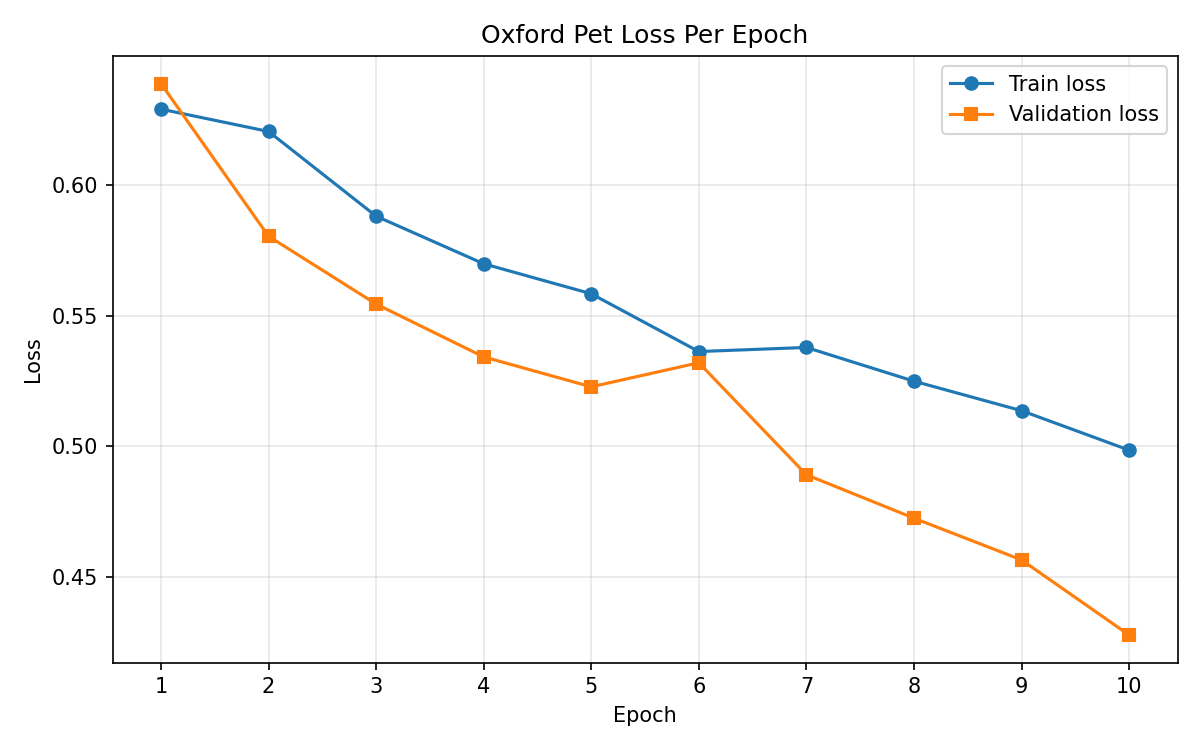

accuracy_curve.png


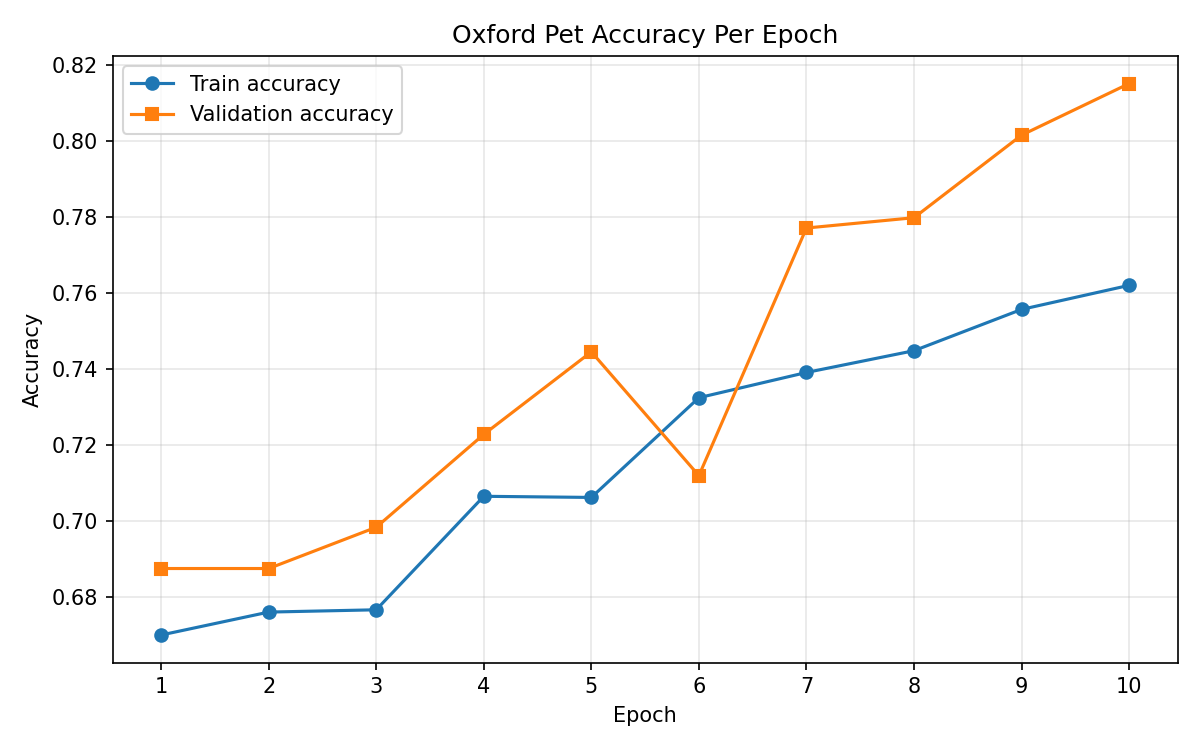

confusion_matrix.png


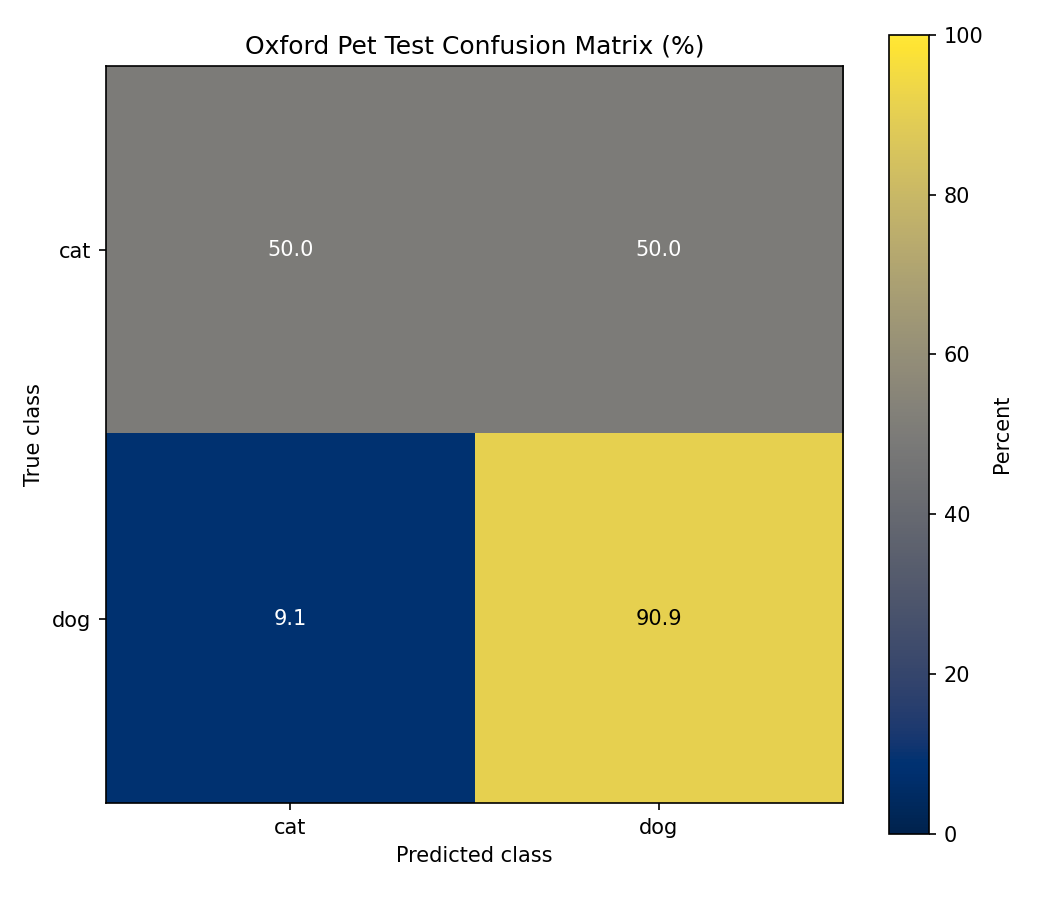

correct_predictions.png


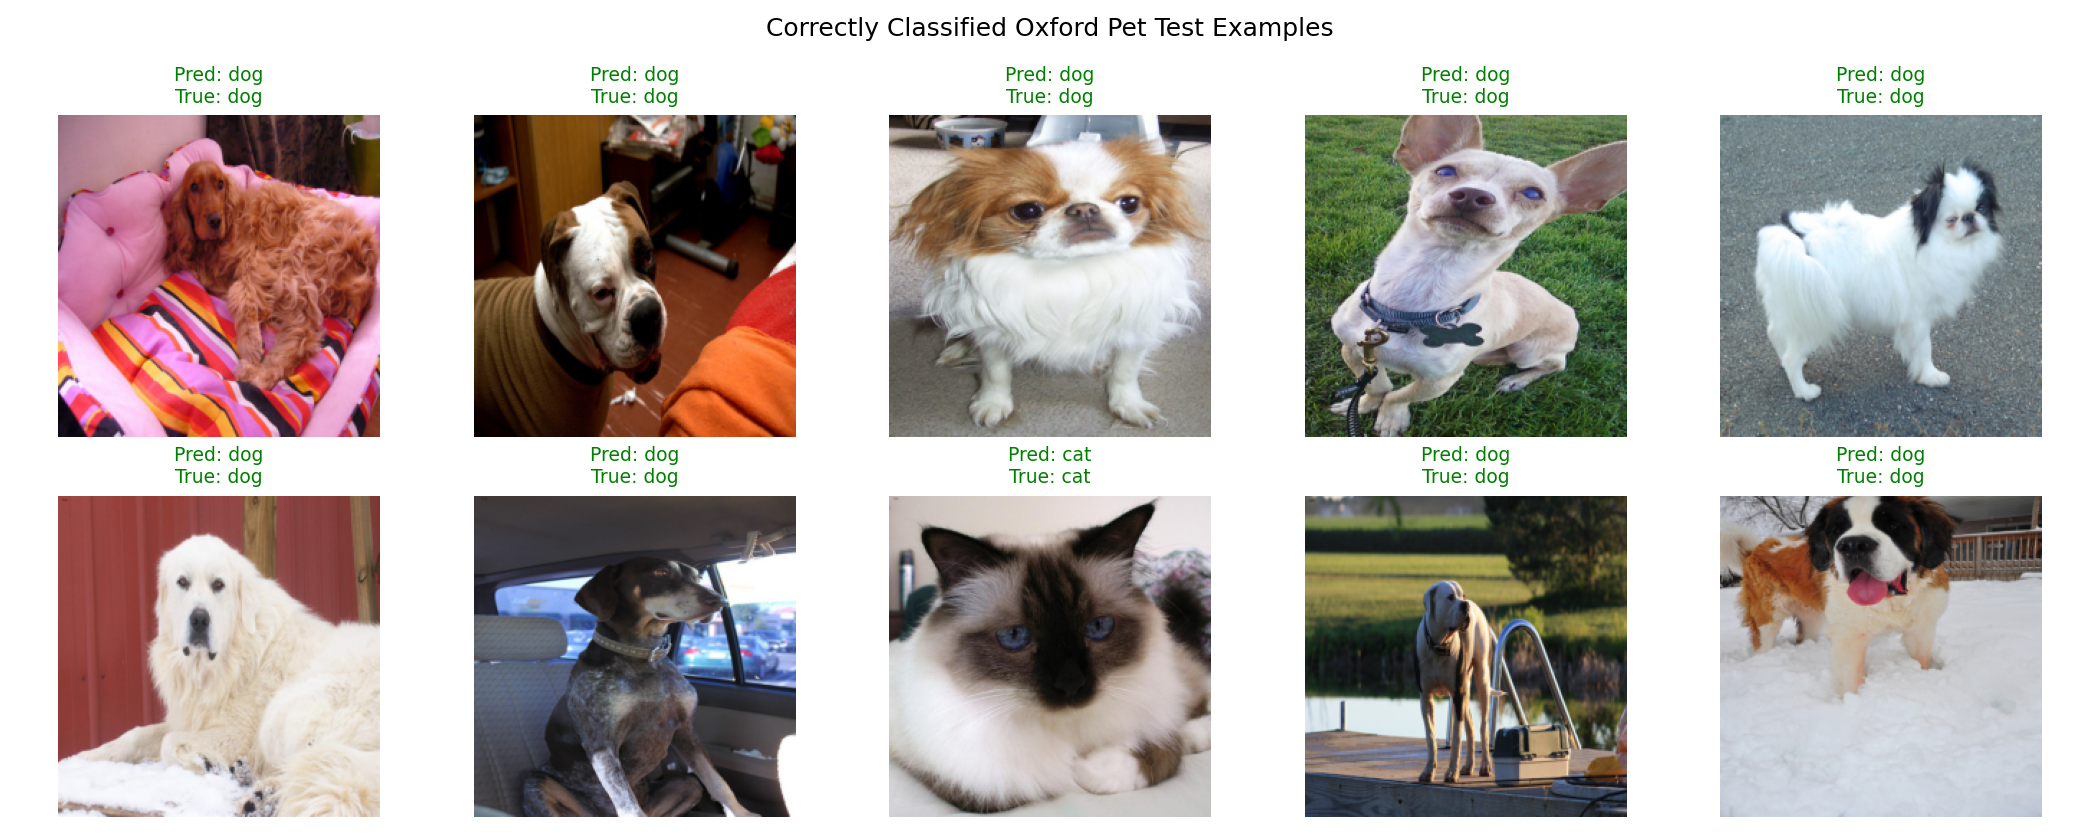

incorrect_predictions.png


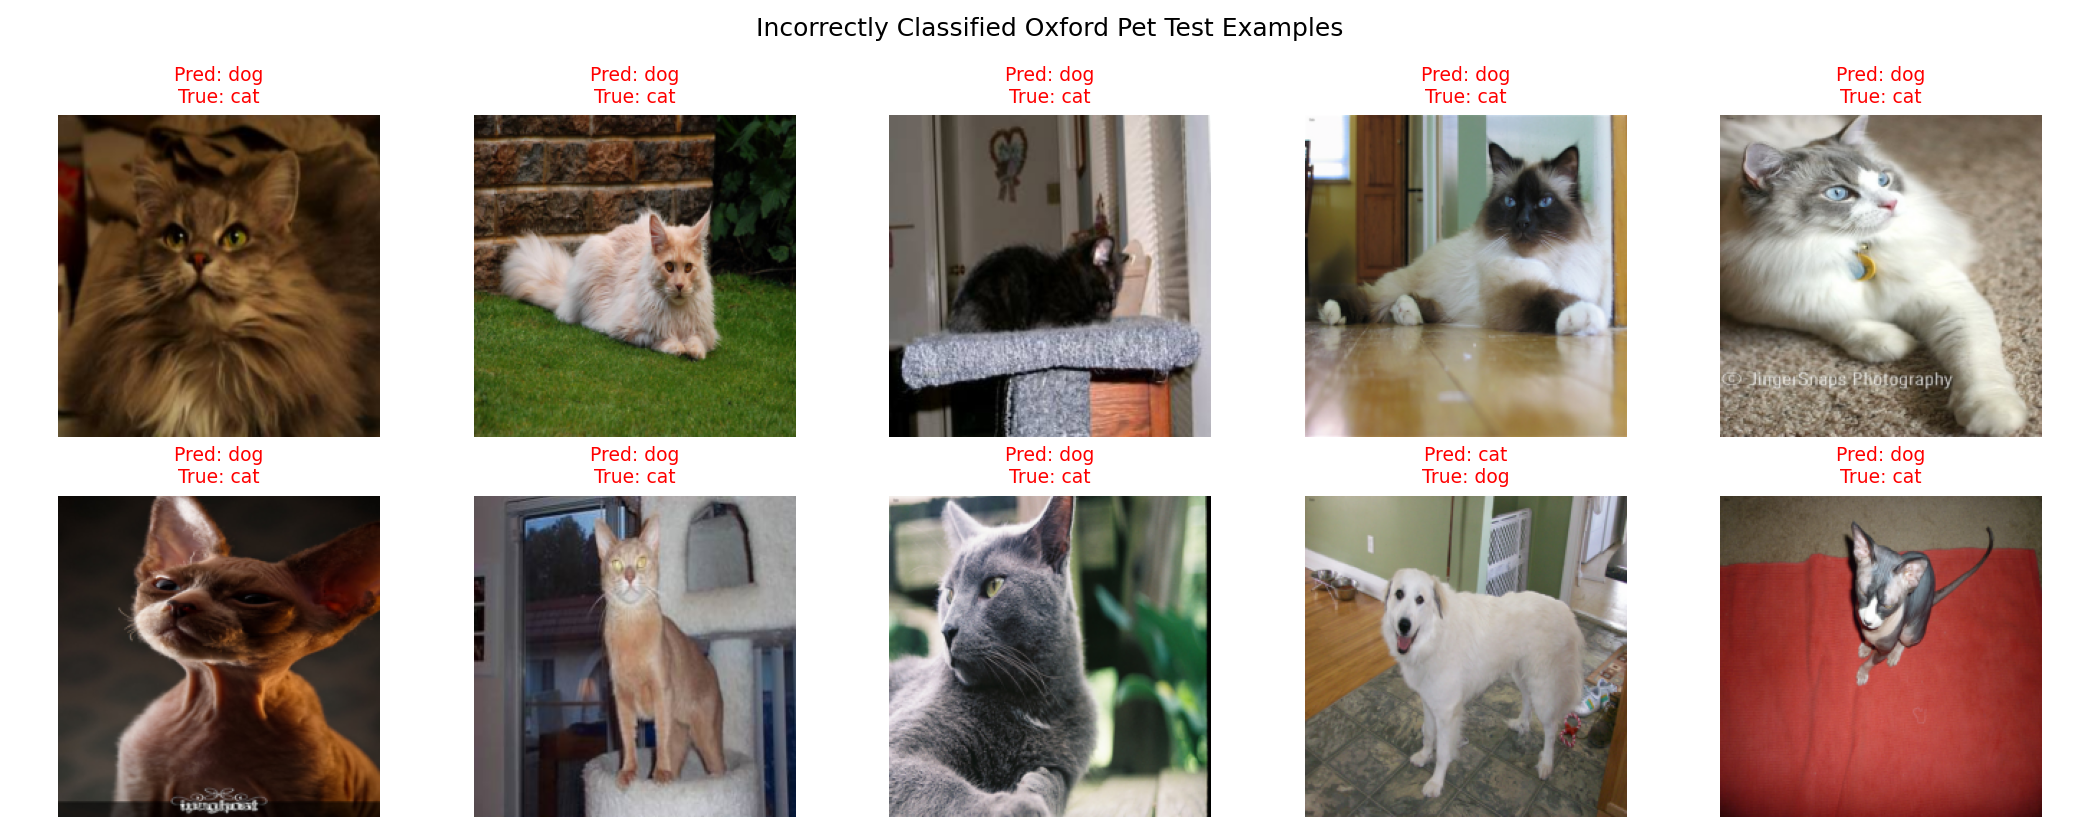

In [5]:
plot_files = [
    'loss_curve.png',
    'accuracy_curve.png',
    'confusion_matrix.png',
    'correct_predictions.png',
    'incorrect_predictions.png',
]
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    print(f'\n## {run_name}')
    for plot_name in plot_files:
        plot_path = run_dir / plot_name
        print(plot_name)
        if plot_path.exists():
            display(Image(filename=str(plot_path)))
        else:
            print('Missing:', plot_path)


## Per-Run Epoch Histories

In [6]:
history_frames = []
for run_name in RUN_NAMES:
    run_dir = Path(RUN_DIRS[run_name])
    history_df = pd.DataFrame(load_json(run_dir / 'training_history.json'))
    history_df['epoch'] = range(1, len(history_df) + 1)
    history_df['model'] = run_name
    history_frames.append(history_df)
history_all = pd.concat(history_frames, ignore_index=True)
history_all.head()

,train_loss,train_accuracy,val_loss,val_accuracy,epoch_duration_seconds,learning_rate,stage,epoch,model
0,0.629040,0.669988,0.638820,0.687500,24.532011,0.001,part2_cnn_deep_wide,1,part2_cnn_deep_wide
1,0.620489,0.676027,0.580387,0.687500,24.251037,0.001,part2_cnn_deep_wide,2,part2_cnn_deep_wide
2,0.588076,0.676630,0.554434,0.698370,24.255717,0.001,part2_cnn_deep_wide,3,part2_cnn_deep_wide
3,0.569850,0.706522,0.534210,0.722826,23.879103,0.001,part2_cnn_deep_wide,4,part2_cnn_deep_wide
4,0.558363,0.706220,0.522744,0.744565,23.618279,0.001,part2_cnn_deep_wide,5,part2_cnn_deep_wide


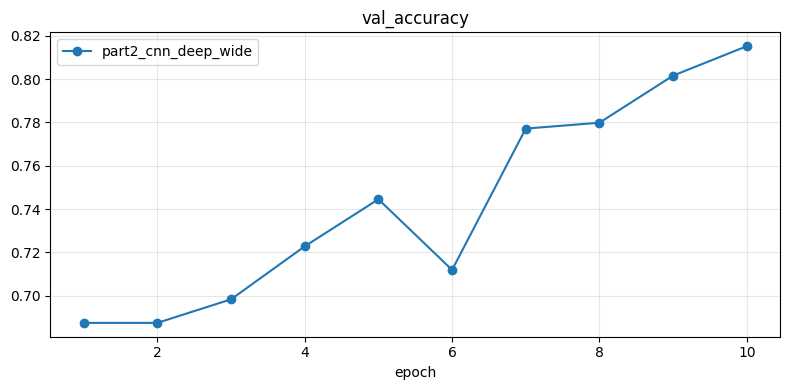

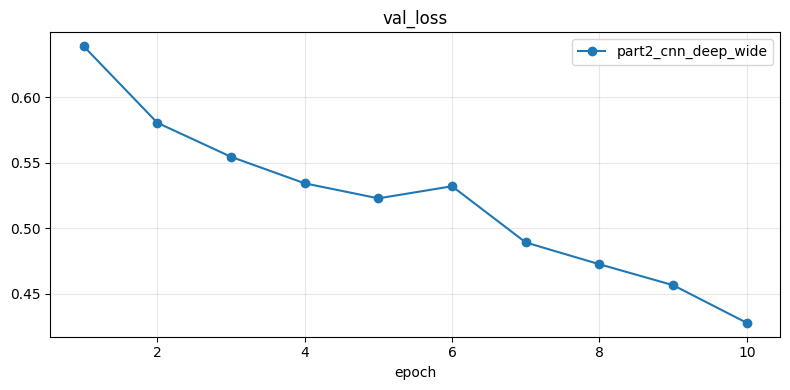

In [7]:
for metric in ['val_accuracy', 'val_loss']:
    plt.figure(figsize=(8, 4))
    for run_name in RUN_NAMES:
        subset = history_all[history_all['model'] == run_name]
        plt.plot(subset['epoch'], subset[metric], marker='o', label=run_name)
    plt.title(metric)
    plt.xlabel('epoch')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Final Remark

In [8]:
best_run = comparison_df.iloc[0]
fastest_run = comparison_df.sort_values(by='time_s', ascending=True).iloc[0]
timed_test_df = comparison_df.dropna(subset=['test_eval_time_s'])
print(f"Best test accuracy: {best_run['model']} ({best_run['test_acc']:.2%})")
print(f"Fastest training run: {fastest_run['model']} ({fastest_run['time_s']:.2f}s)")
if not timed_test_df.empty:
    fastest_test_run = timed_test_df.sort_values(by='test_eval_time_s', ascending=True).iloc[0]
    print(f"Fastest test evaluation: {fastest_test_run['model']} ({fastest_test_run['test_eval_time_s']:.2f}s)")
else:
    print('Fastest test evaluation: unavailable in these summaries')

Best test accuracy: part2_cnn_deep_wide (77.11%)
Fastest training run: part2_cnn_deep_wide (242.02s)
Fastest test evaluation: part2_cnn_deep_wide (1.32s)
